<a href="https://colab.research.google.com/github/juanjomar22-glitch/Juan.Marquez/blob/main/Parcial_I_Integracion_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parcial I - Integración de Datos y Prospectiva
## Caso de Estudio: Entidad Prestadora de Salud
**Variable de referencia:** BMI (Índice de Masa Corporal) por las siguientes razones:

1. Es la única variable numérica continua presente en todas las sucursales,
   incluyendo Itagui, que no cuenta con la variable Glucose.

2. El BMI tiene una relación clínica directa con la diabetes tipo 2, ya que
   el exceso de tejido adiposo genera resistencia a la insulina, mecanismo
   central de la enfermedad.

3. Es una variable estandarizada y comparable entre poblaciones, lo que
   la hace adecuada para medir afinidad entre sucursales mediante la
   Teoría de la Credibilidad.

Las demás variables comunes a todas las sucursales son: BloodPressure,
SkinThickness, Insulin, DiabetesPedigreeFunction y Age. Sin embargo,
el BMI es la más representativa para caracterizar el perfil general
de un paciente con riesgo de diabetes.

**Objetivo:** La entidad prestadora de salud quiere cerrar la sucursal de
Sabaneta y reubicar sus pacientes en las demás sucursales (Bello, Medellín,
Envigado, Itagui, Caldas).

## 0. Carga de librerías de trabajo

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Carga de los archivos de trabajo

In [34]:
nxl = "/content/drive/MyDrive/Linea de enfasis/Integracion de datos y prospectiva/Parcial 1/3. Parcial - medical_attention_data.xlsx"

# Se carga cada sucursal
XDB_Bello    = pd.read_excel(nxl, sheet_name='Bello')
XDB_Medellin = pd.read_excel(nxl, sheet_name='Medellín')
XDB_Envigado = pd.read_excel(nxl, sheet_name='Envigado')
XDB_Itagui   = pd.read_excel(nxl, sheet_name='Itagui')
XDB_Sabaneta = pd.read_excel(nxl, sheet_name='Sabaneta')
XDB_Caldas   = pd.read_excel(nxl, sheet_name='Caldas')

print("Sabaneta (sucursal a cerrar):")
XDB_Sabaneta.head(10)

Sabaneta (sucursal a cerrar):


,PatientID,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetes,Branch
0,SAB-0001,196,101,0,321,31.010,0.352,80,0,Sabaneta
1,SAB-0002,93,115,17,366,27.789,1.846,31,0,Sabaneta
2,SAB-0003,95,73,37,135,44.594,1.461,63,1,Sabaneta
3,SAB-0004,94,91,19,191,23.219,1.303,22,0,Sabaneta
4,SAB-0005,189,47,22,600,24.747,0.993,43,1,Sabaneta
5,SAB-0006,185,58,34,619,33.292,0.589,30,0,Sabaneta
6,SAB-0007,108,92,6,284,30.470,1.493,46,1,Sabaneta
7,SAB-0008,191,110,54,435,34.060,1.279,80,1,Sabaneta
8,SAB-0009,196,45,17,490,21.073,2.444,69,0,Sabaneta
9,SAB-0010,163,62,33,834,29.303,1.329,40,1,Sabaneta


In [4]:
# Se extraen los datos de BMI (variable de referencia para pacientes con Diabetes)
BMI_Bello    = XDB_Bello['BMI']
BMI_Medellin = XDB_Medellin['BMI']
BMI_Envigado = XDB_Envigado['BMI']
BMI_Itagui   = XDB_Itagui['BMI']
BMI_Sabaneta = XDB_Sabaneta['BMI']
BMI_Caldas   = XDB_Caldas['BMI']

print("Número de pacientes por sucursal:")
print("Bello:",    len(BMI_Bello))
print("Medellín:", len(BMI_Medellin))
print("Envigado:", len(BMI_Envigado))
print("Itagui:",   len(BMI_Itagui))
print("Sabaneta:", len(BMI_Sabaneta))
print("Caldas:",   len(BMI_Caldas))

Número de pacientes por sucursal:
Bello: 502
Medellín: 895
Envigado: 792
Itagui: 684
Sabaneta: 621
Caldas: 909


## 2. Método de Caracterización de Variables Aleatorias
Se define la función de caracterización utilizada en clase para calcular las medidas de tendencia central y dispersión.

In [5]:
def Caracterizacion_VA(X, titulo='Variable'):
    # Se procede con la construcción de la distribución
    plt.figure(figsize=(10,5))
    sns.histplot(X, bins=10, kde=True)
    plt.xlabel(titulo)
    plt.grid()
    plt.show()

    NI = 10  # Número de clusters
    counts, bin_edges = np.histogram(X, bins=NI)
    XC = (bin_edges[:-1] + bin_edges[1:]) / 2
    prob = counts / np.sum(counts)

    # Medidas de tendencia central
    u     = np.sum(XC * prob)
    var   = np.sum(prob * (XC - u)**2)
    sigma = np.sqrt(var)
    CAs   = np.sum(prob * (XC - u)**3) / sigma**3
    kur   = (np.sum(prob * (XC - u)**4) / sigma**4) - 3

    return u, var, sigma, CAs, kur

## 3. Caracterización ANTES de la integración
Se calculan las medidas estadísticas para cada sucursal antes de integrar los pacientes de Sabaneta.

===== BELLO =====


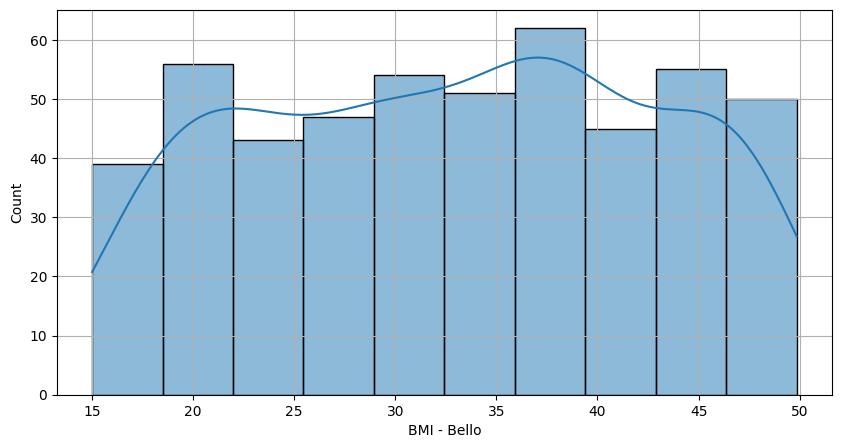

===== MEDELLÍN =====


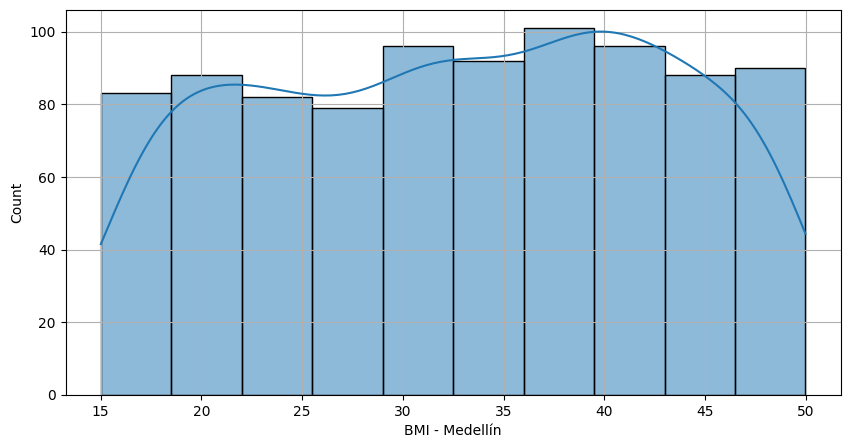

===== ENVIGADO =====


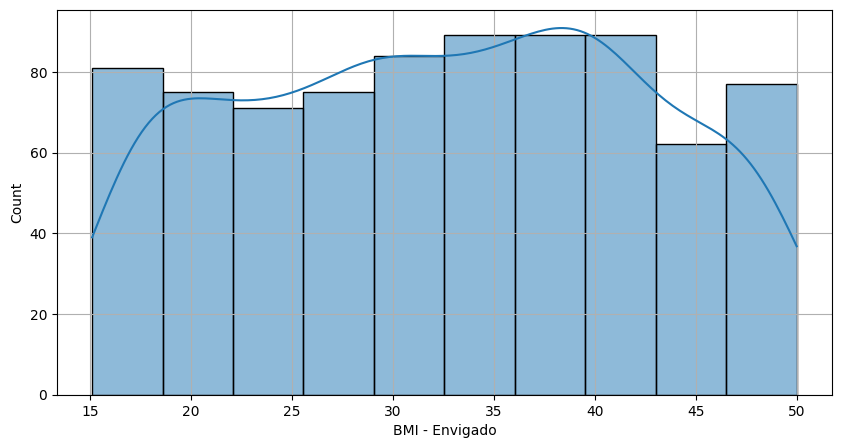

===== ITAGUI =====


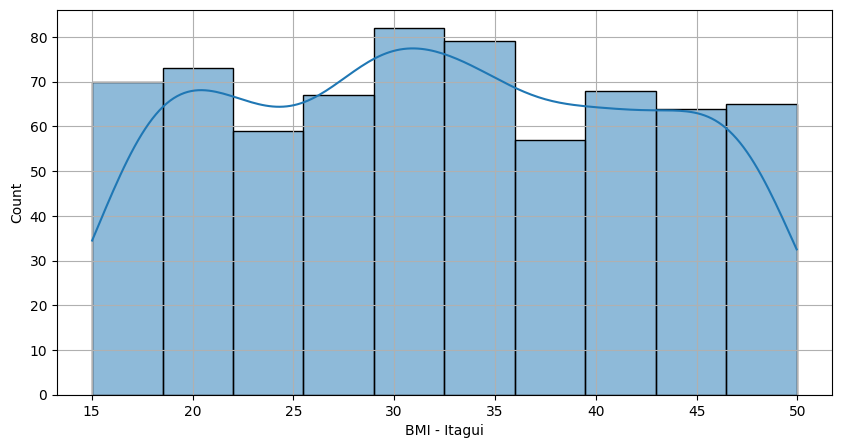

===== SABANETA (sucursal a cerrar) =====


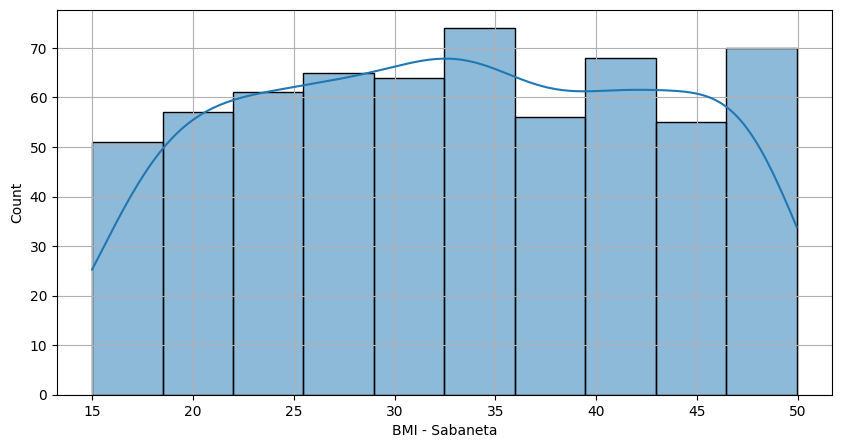

===== CALDAS =====


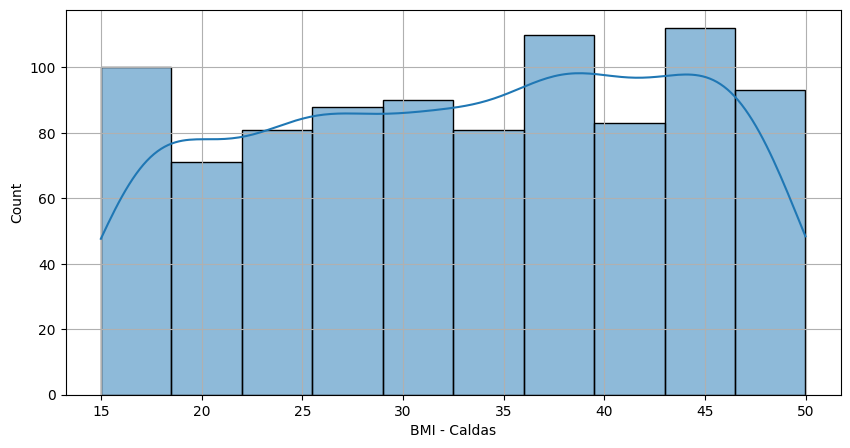

In [6]:
np.set_printoptions(suppress=True)

print("===== BELLO =====")
u_B, var_B, sigma_B, CAs_B, kur_B = Caracterizacion_VA(BMI_Bello, 'BMI - Bello')

print("===== MEDELLÍN =====")
u_M, var_M, sigma_M, CAs_M, kur_M = Caracterizacion_VA(BMI_Medellin, 'BMI - Medellín')

print("===== ENVIGADO =====")
u_E, var_E, sigma_E, CAs_E, kur_E = Caracterizacion_VA(BMI_Envigado, 'BMI - Envigado')

print("===== ITAGUI =====")
u_I, var_I, sigma_I, CAs_I, kur_I = Caracterizacion_VA(BMI_Itagui, 'BMI - Itagui')

print("===== SABANETA (sucursal a cerrar) =====")
u_S, var_S, sigma_S, CAs_S, kur_S = Caracterizacion_VA(BMI_Sabaneta, 'BMI - Sabaneta')

print("===== CALDAS =====")
u_C, var_C, sigma_C, CAs_C, kur_C = Caracterizacion_VA(BMI_Caldas, 'BMI - Caldas')

In [7]:
# Tabla resumen ANTES de la integración
Tabla_antes = np.column_stack((
    [u_B,    u_M,    u_E,    u_I,    u_S,    u_C],
    [var_B,  var_M,  var_E,  var_I,  var_S,  var_C],
    [sigma_B,sigma_M,sigma_E,sigma_I,sigma_S,sigma_C],
    [CAs_B,  CAs_M,  CAs_E,  CAs_I,  CAs_S,  CAs_C],
    [kur_B,  kur_M,  kur_E,  kur_I,  kur_S,  kur_C]
))
df_antes = pd.DataFrame(Tabla_antes,
                        columns=['Media','Varianza','Desviacion','Asimetria','Curtosis'],
                        index=['Bello','Medellín','Envigado','Itagui','Sabaneta','Caldas'])
print("Medidas estadísticas ANTES de la integración:")
display(df_antes)

Medidas estadísticas ANTES de la integración:


,Media,Varianza,Desviacion,Asimetria,Curtosis
Bello,32.927841,96.125665,9.804370,-0.059945,-1.186052
Medellín,32.870382,98.518551,9.925651,-0.069743,-1.188015
Envigado,32.566531,96.716255,9.834442,-0.040160,-1.149184
Itagui,32.246765,98.583962,9.928946,0.027262,-1.172182
Sabaneta,32.965825,96.783636,9.837867,-0.025742,-1.162783
Caldas,33.052491,102.870531,10.142511,-0.110526,-1.218174


## 4. Teoría de la Credibilidad
Se estima la afinidad (credibilidad) entre Sabaneta (sucursal a cerrar) y cada una de las demás sucursales.

In [32]:
def credibilidad(BMI_interna, BMI_externa, nombre_interna, nombre_externa):
    ND_int = len(BMI_interna)
    ND_ext = len(BMI_externa)

    u_int = np.mean(BMI_interna)
    u_ext = np.mean(BMI_externa)
    sigma2_int = np.var(BMI_interna)
    sigma2_ext = np.var(BMI_externa)

    # Valor esperado de la varianza (EPV)
    EPV = (sigma2_int * ND_int + sigma2_ext * ND_ext) / (ND_int + ND_ext)

    # Valor hipotético de la media (VHM)
    uh  = (u_int * ND_int + u_ext * ND_ext) / (ND_int + ND_ext)
    VHM = ((ND_int * u_int**2 + ND_ext * u_ext**2) / (ND_int + ND_ext)) - uh**2

    # Factor de credibilidad
    fc = EPV / VHM

    # Credibilidad
    Cr = ND_int / (ND_int + fc)

    print("\n----------------------------------------")
    print(f"{nombre_interna} vs Sabaneta")
    print(f"  Media {nombre_interna}:  {u_int:.4f}")
    print(f"  Media {nombre_externa}: {u_ext:.4f}")
    print(f"  EPV: {EPV:.4f}")
    print(f"  VHM: {VHM:.4f}")
    print(f"  fc:  {fc:.4f}")
    print(f"  Credibilidad: {Cr:.4f} ({Cr*100:.2f}%)")
    return Cr

Cr_B = credibilidad(BMI_Bello,    BMI_Sabaneta, 'Bello',    'Sabaneta')
Cr_M = credibilidad(BMI_Medellin, BMI_Sabaneta, 'Medellín', 'Sabaneta')
Cr_E = credibilidad(BMI_Envigado, BMI_Sabaneta, 'Envigado', 'Sabaneta')
Cr_I = credibilidad(BMI_Itagui,   BMI_Sabaneta, 'Itagui',   'Sabaneta')
Cr_C = credibilidad(BMI_Caldas,   BMI_Sabaneta, 'Caldas',   'Sabaneta')


----------------------------------------
Bello vs Sabaneta
  Media Bello:  32.9905
  Media Sabaneta: 32.9921
  EPV: 97.6176
  VHM: 0.0000
  fc:  158289400.8632
  Credibilidad: 0.0000 (0.00%)

----------------------------------------
Medellín vs Sabaneta
  Media Medellín:  32.8798
  Media Sabaneta: 32.9921
  EPV: 98.7312
  VHM: 0.0031
  fc:  32368.9143
  Credibilidad: 0.0269 (2.69%)

----------------------------------------
Envigado vs Sabaneta
  Media Envigado:  32.5505
  Media Sabaneta: 32.9921
  EPV: 97.0224
  VHM: 0.0480
  fc:  2019.9062
  Credibilidad: 0.2817 (28.17%)

----------------------------------------
Itagui vs Sabaneta
  Media Itagui:  32.2412
  Media Sabaneta: 32.9921
  EPV: 98.5085
  VHM: 0.1406
  fc:  700.4585
  Credibilidad: 0.4941 (49.41%)

----------------------------------------
Caldas vs Sabaneta
  Media Caldas:  33.0635
  Media Sabaneta: 32.9921
  EPV: 101.5348
  VHM: 0.0012
  fc:  82516.6055
  Credibilidad: 0.0109 (1.09%)


In [31]:
# Tabla resumen de credibilidades
Tabla_cr = np.column_stack(([Cr_B, Cr_M, Cr_E, Cr_I, Cr_C],
                             [Cr_B*100, Cr_M*100, Cr_E*100, Cr_I*100, Cr_C*100]))
df_cr = pd.DataFrame(Tabla_cr,
                     columns=['Credibilidad','Credibilidad (%)'],
                     index=['Sabaneta-Bello','Sabaneta-Medellín','Sabaneta-Envigado','Sabaneta-Itagui','Sabaneta-Caldas'])
print("Resumen de Credibilidades entre Sabaneta y las demás sucursales:")
display(df_cr)

# Ordenar sucursales por credibilidad de mayor a menor
nombres  = ['Bello', 'Medellín', 'Envigado', 'Itagui', 'Caldas']
creds    = [Cr_B, Cr_M, Cr_E, Cr_I, Cr_C]
orden    = np.argsort(creds)[::-1]

print("Orden de sucursales para reubicar pacientes de Sabaneta (de mayor a menor afinidad):")
for i in orden:
    print(f"  {nombres[i]}: Cr = {creds[i]:.4f} ({creds[i]*100:.2f}%)")

print(f"\nLa sucursal con mayor afinidad a Sabaneta es: {nombres[orden[0]]} ({creds[orden[0]]*100:.2f}%)")
print("Esta sucursal es la candidata principal para recibir los pacientes de Sabaneta.")

Resumen de Credibilidades entre Sabaneta y las demás sucursales:


,Credibilidad,Credibilidad (%)
Sabaneta-Bello,0.000003,0.000317
Sabaneta-Medellín,0.026906,2.690603
Sabaneta-Envigado,0.281659,28.165947
Sabaneta-Itagui,0.494056,49.405599
Sabaneta-Caldas,0.010896,1.089594


Orden de sucursales para reubicar pacientes de Sabaneta (de mayor a menor afinidad):
  Itagui: Cr = 0.4941 (49.41%)
  Envigado: Cr = 0.2817 (28.17%)
  Medellín: Cr = 0.0269 (2.69%)
  Caldas: Cr = 0.0109 (1.09%)
  Bello: Cr = 0.0000 (0.00%)

La sucursal con mayor afinidad a Sabaneta es: Itagui (49.41%)
Esta sucursal es la candidata principal para recibir los pacientes de Sabaneta.


## 5. Integración por Valor de Pertenencia
Se reubicarán los pacientes de Sabaneta en las demás sucursales utilizando el método del valor de pertenencia (VP). Un paciente es integrado si su VP > 0.9.

In [26]:
def integracion_VP(BMI_interna, XDB_externa, u_interna, sigma_interna, nombre):
    BMI_ext  = np.array(XDB_externa['BMI'])
    BMI_int  = np.copy(np.array(BMI_interna))  # Variable de integración
    IDs_ext  = np.array(XDB_externa['PatientID'])

    m1 = 0
    pacientes_integrados = []

    for k in range(len(BMI_ext)):
        VP = np.exp(-0.5 * ((u_interna - BMI_ext[k]) / sigma_interna)**2)

        if VP > 0.9:
            m1 = m1 + 1
            BMI_int = np.append(BMI_int, BMI_ext[k])
            pacientes_integrados.append(IDs_ext[k])

    print(f"\nPacientes de Sabaneta integrados a {nombre}: {m1}")
    return BMI_int, m1, pacientes_integrados

# Integración de pacientes de Sabaneta en cada sucursal
BMI_Bello_int,    m_B, pacs_B = integracion_VP(BMI_Bello,    XDB_Sabaneta, u_B, sigma_B, 'Bello')
BMI_Medellin_int, m_M, pacs_M = integracion_VP(BMI_Medellin, XDB_Sabaneta, u_M, sigma_M, 'Medellín')
BMI_Envigado_int, m_E, pacs_E = integracion_VP(BMI_Envigado, XDB_Sabaneta, u_E, sigma_E, 'Envigado')
BMI_Itagui_int,   m_I, pacs_I = integracion_VP(BMI_Itagui,   XDB_Sabaneta, u_I, sigma_I, 'Itagui')
BMI_Caldas_int,   m_C, pacs_C = integracion_VP(BMI_Caldas,   XDB_Sabaneta, u_C, sigma_C, 'Caldas')

print("\nTotal pacientes de Sabaneta:", len(BMI_Sabaneta))
print("Total asignaciones VP:", m_B + m_M + m_E + m_I + m_C)


Pacientes de Sabaneta integrados a Bello: 177

Pacientes de Sabaneta integrados a Medellín: 178

Pacientes de Sabaneta integrados a Envigado: 172

Pacientes de Sabaneta integrados a Itagui: 173

Pacientes de Sabaneta integrados a Caldas: 178

Total pacientes de Sabaneta: 621
Total asignaciones VP: 878


===== BELLO - después integración VP =====


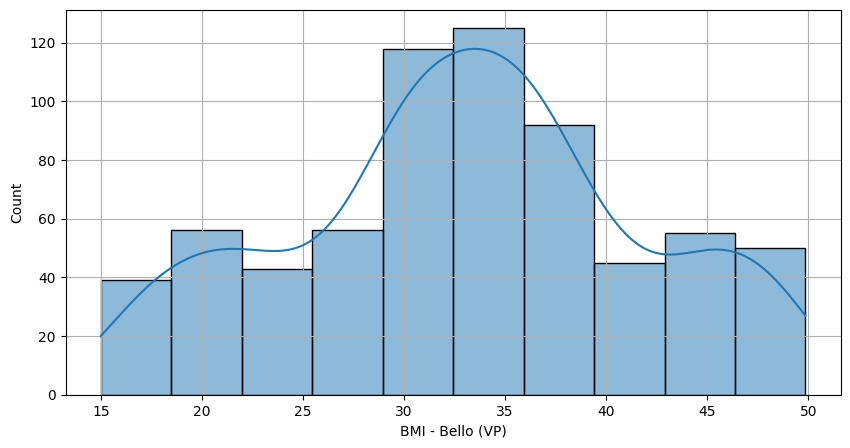

===== MEDELLÍN - después integración VP =====


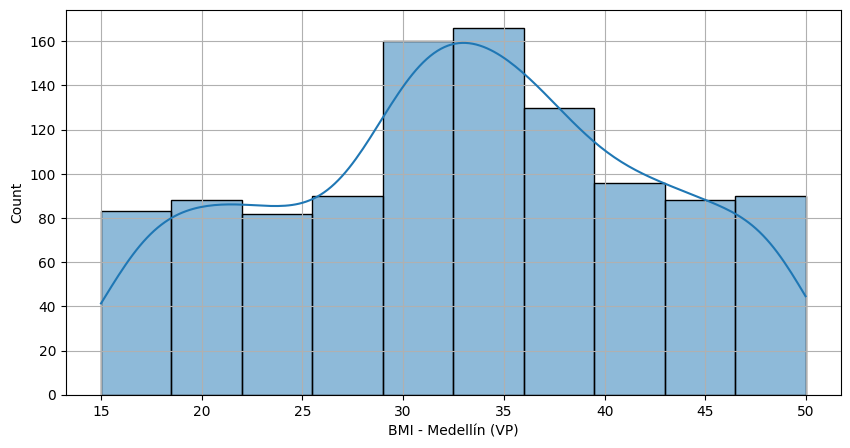

===== ENVIGADO - después integración VP =====


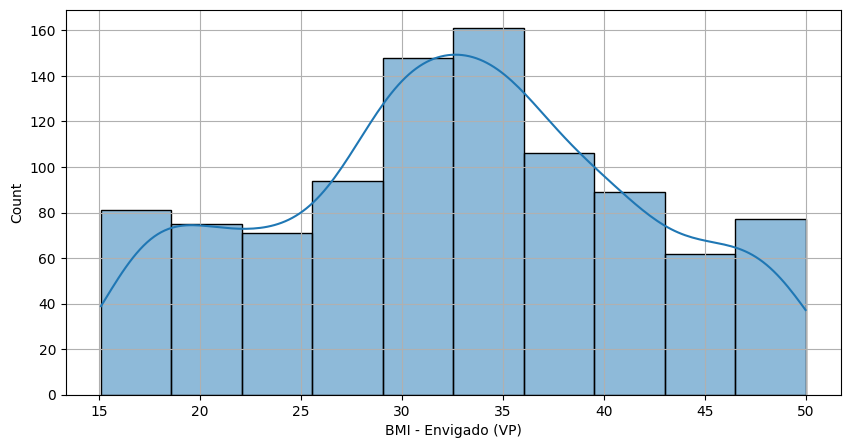

===== ITAGUI - después integración VP =====


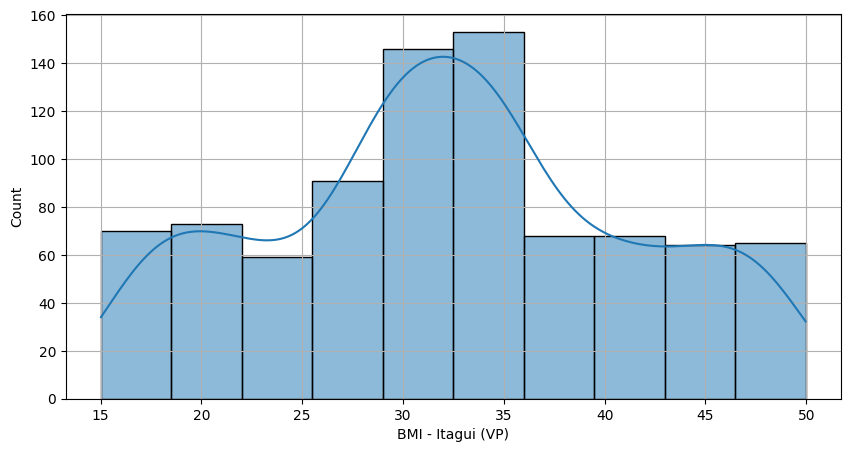

===== CALDAS - después integración VP =====


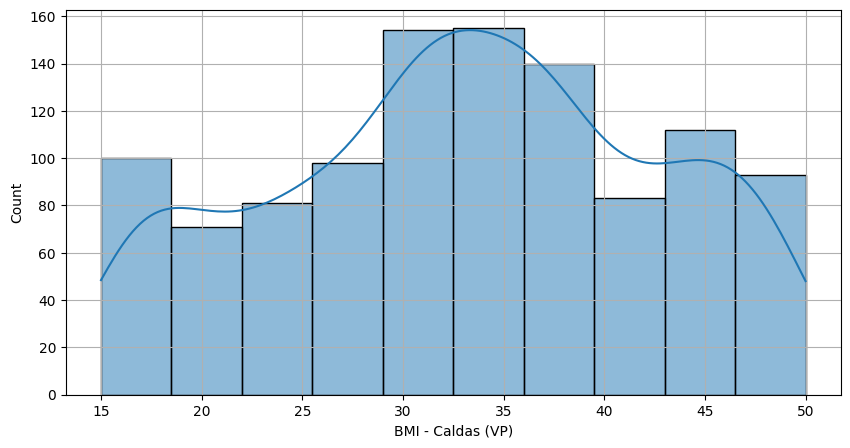

In [12]:
# Caracterización DESPUÉS de la integración por VP
print("===== BELLO - después integración VP =====")
ui_B_VP, vari_B_VP, sigmai_B_VP, CAsi_B_VP, kuri_B_VP = Caracterizacion_VA(BMI_Bello_int, 'BMI - Bello (VP)')

print("===== MEDELLÍN - después integración VP =====")
ui_M_VP, vari_M_VP, sigmai_M_VP, CAsi_M_VP, kuri_M_VP = Caracterizacion_VA(BMI_Medellin_int, 'BMI - Medellín (VP)')

print("===== ENVIGADO - después integración VP =====")
ui_E_VP, vari_E_VP, sigmai_E_VP, CAsi_E_VP, kuri_E_VP = Caracterizacion_VA(BMI_Envigado_int, 'BMI - Envigado (VP)')

print("===== ITAGUI - después integración VP =====")
ui_I_VP, vari_I_VP, sigmai_I_VP, CAsi_I_VP, kuri_I_VP = Caracterizacion_VA(BMI_Itagui_int, 'BMI - Itagui (VP)')

print("===== CALDAS - después integración VP =====")
ui_C_VP, vari_C_VP, sigmai_C_VP, CAsi_C_VP, kuri_C_VP = Caracterizacion_VA(BMI_Caldas_int, 'BMI - Caldas (VP)')

In [13]:
# Tabla comparativa ANTES vs DESPUÉS - Valor de Pertenencia
print("\nDiscrepancia en la media ANTES vs DESPUÉS (Valor de Pertenencia):")
for nombre, u_antes, u_desp in [
    ('Bello',    u_B, ui_B_VP),
    ('Medellín', u_M, ui_M_VP),
    ('Envigado', u_E, ui_E_VP),
    ('Itagui',   u_I, ui_I_VP),
    ('Caldas',   u_C, ui_C_VP)
]:
    disc = np.abs((u_antes - u_desp) / u_antes) * 100
    print(f"  {nombre}: Media antes={u_antes:.4f} | Media después={u_desp:.4f} | Discrepancia={disc:.2f}%")


Discrepancia en la media ANTES vs DESPUÉS (Valor de Pertenencia):
  Bello: Media antes=32.9278 | Media después=32.9849 | Discrepancia=0.17%
  Medellín: Media antes=32.8704 | Media después=32.9115 | Discrepancia=0.12%
  Envigado: Media antes=32.5665 | Media después=32.5662 | Discrepancia=0.00%
  Itagui: Media antes=32.2468 | Media después=32.2371 | Discrepancia=0.03%
  Caldas: Media antes=33.0525 | Media después=33.0734 | Discrepancia=0.06%


## 6. Integración por Aceptación y Rechazo
Se repite el procedimiento de integración utilizando el método de Aceptación y Rechazo. Un paciente es aceptado si su BMI cae dentro del intervalo [u - sigma, u + sigma] de la sucursal receptora.

In [29]:
def integracion_AR(BMI_interna, XDB_externa, u_interna, sigma_interna, nombre):
    BMI_ext  = np.array(XDB_externa['BMI'])
    BMI_int  = np.copy(np.array(BMI_interna))  # Variable de integración
    IDs_ext  = np.array(XDB_externa['PatientID'])

    LI = u_interna - sigma_interna   # Límite inferior de aceptación
    LS = u_interna + sigma_interna   # Límite superior de aceptación

    m1 = 0
    pacientes_integrados = []

    for k in range(len(BMI_ext)):
        if LI <= BMI_ext[k] <= LS:
            m1 = m1 + 1
            BMI_int = np.append(BMI_int, BMI_ext[k])
            pacientes_integrados.append(IDs_ext[k])

    print(f"\nPacientes de Sabaneta integrados a {nombre} (A/R): {m1}")
    return BMI_int, m1, pacientes_integrados

# Integración por Aceptación y Rechazo
BMI_Bello_AR,    m_B_AR, pacs_B_AR = integracion_AR(BMI_Bello,    XDB_Sabaneta, u_B, sigma_B, 'Bello')
BMI_Medellin_AR, m_M_AR, pacs_M_AR = integracion_AR(BMI_Medellin, XDB_Sabaneta, u_M, sigma_M, 'Medellín')
BMI_Envigado_AR, m_E_AR, pacs_E_AR = integracion_AR(BMI_Envigado, XDB_Sabaneta, u_E, sigma_E, 'Envigado')
BMI_Itagui_AR,   m_I_AR, pacs_I_AR = integracion_AR(BMI_Itagui,   XDB_Sabaneta, u_I, sigma_I, 'Itagui')
BMI_Caldas_AR,   m_C_AR, pacs_C_AR = integracion_AR(BMI_Caldas,   XDB_Sabaneta, u_C, sigma_C, 'Caldas')

print("\nTotal pacientes de Sabaneta:", len(BMI_Sabaneta))
print("Total asignaciones A/R:", m_B_AR + m_M_AR + m_E_AR + m_I_AR + m_C_AR)


Pacientes de Sabaneta integrados a Bello (A/R): 364

Pacientes de Sabaneta integrados a Medellín (A/R): 368

Pacientes de Sabaneta integrados a Envigado (A/R): 361

Pacientes de Sabaneta integrados a Itagui (A/R): 363

Pacientes de Sabaneta integrados a Caldas (A/R): 374

Total pacientes de Sabaneta: 621
Total asignaciones A/R: 1830


===== BELLO - después integración A/R =====


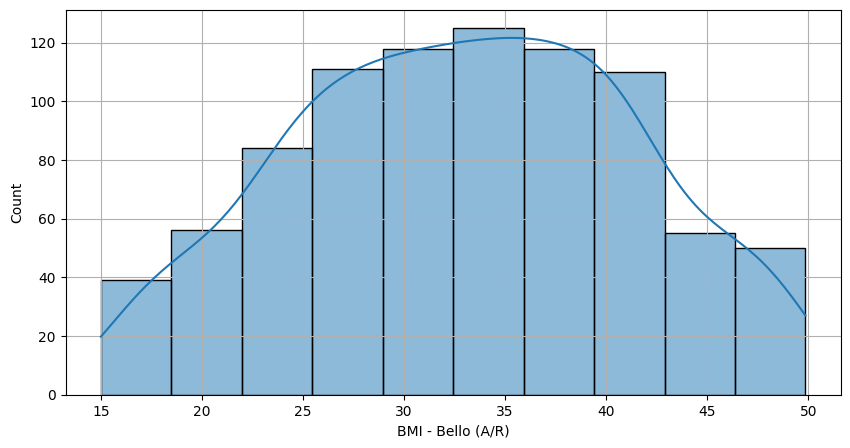

===== MEDELLÍN - después integración A/R =====


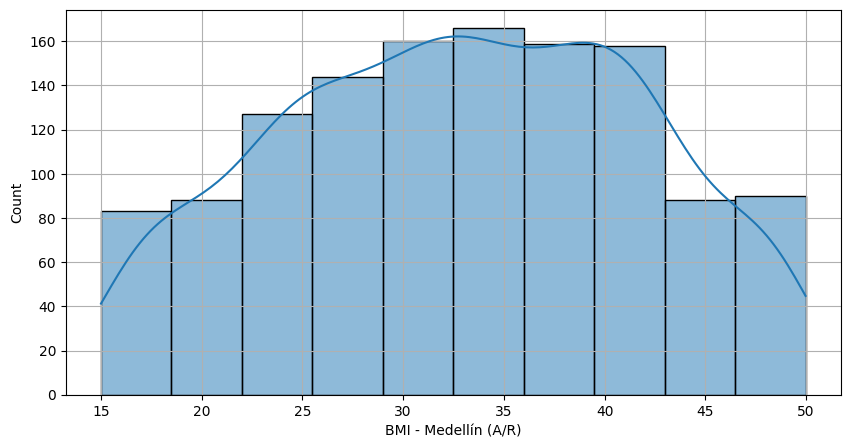

===== ENVIGADO - después integración A/R =====


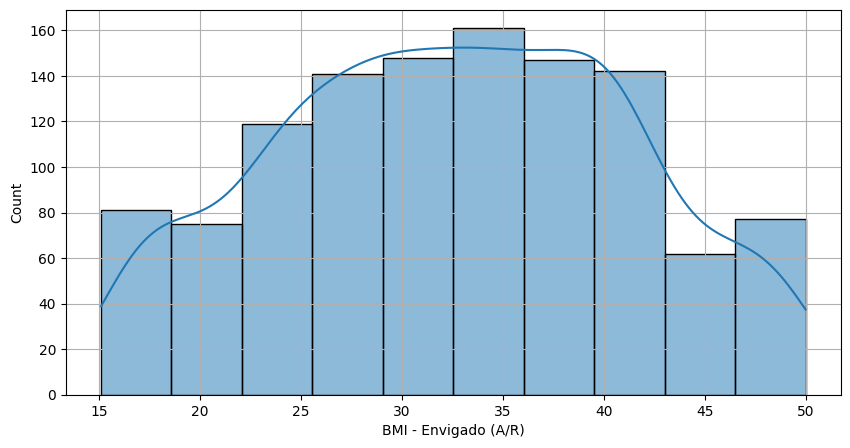

===== ITAGUI - después integración A/R =====


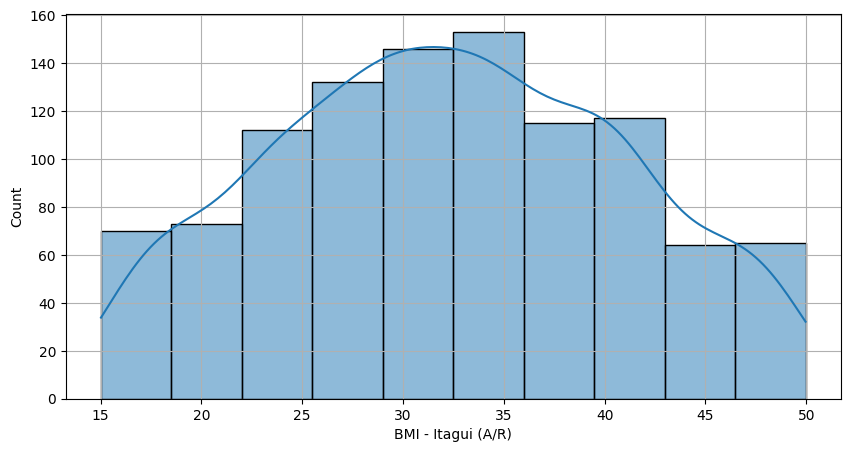

===== CALDAS - después integración A/R =====


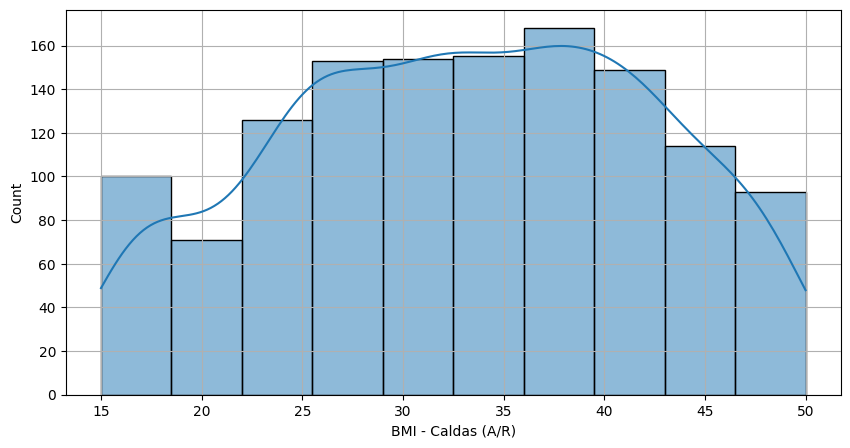

In [15]:
# Caracterización DESPUÉS de la integración por Aceptación y Rechazo
print("===== BELLO - después integración A/R =====")
ui_B_AR, vari_B_AR, sigmai_B_AR, CAsi_B_AR, kuri_B_AR = Caracterizacion_VA(BMI_Bello_AR, 'BMI - Bello (A/R)')

print("===== MEDELLÍN - después integración A/R =====")
ui_M_AR, vari_M_AR, sigmai_M_AR, CAsi_M_AR, kuri_M_AR = Caracterizacion_VA(BMI_Medellin_AR, 'BMI - Medellín (A/R)')

print("===== ENVIGADO - después integración A/R =====")
ui_E_AR, vari_E_AR, sigmai_E_AR, CAsi_E_AR, kuri_E_AR = Caracterizacion_VA(BMI_Envigado_AR, 'BMI - Envigado (A/R)')

print("===== ITAGUI - después integración A/R =====")
ui_I_AR, vari_I_AR, sigmai_I_AR, CAsi_I_AR, kuri_I_AR = Caracterizacion_VA(BMI_Itagui_AR, 'BMI - Itagui (A/R)')

print("===== CALDAS - después integración A/R =====")
ui_C_AR, vari_C_AR, sigmai_C_AR, CAsi_C_AR, kuri_C_AR = Caracterizacion_VA(BMI_Caldas_AR, 'BMI - Caldas (A/R)')

In [30]:
# Tabla comparativa ANTES vs DESPUÉS - Aceptación y Rechazo
print("\nDiscrepancia en la media ANTES vs DESPUÉS (Aceptación y Rechazo):")
for nombre, u_antes, u_desp in [
    ('Bello',    u_B, ui_B_AR),
    ('Medellín', u_M, ui_M_AR),
    ('Envigado', u_E, ui_E_AR),
    ('Itagui',   u_I, ui_I_AR),
    ('Caldas',   u_C, ui_C_AR)
]:
    disc = np.abs((u_antes - u_desp) / u_antes) * 100
    print(f"  {nombre}: Media antes={u_antes:.4f} | Media después={u_desp:.4f} | Discrepancia={disc:.2f}%")


Discrepancia en la media ANTES vs DESPUÉS (Aceptación y Rechazo):
  Bello: Media antes=32.9278 | Media después=32.9310 | Discrepancia=0.01%
  Medellín: Media antes=32.8704 | Media después=32.8618 | Discrepancia=0.03%
  Envigado: Media antes=32.5665 | Media después=32.5733 | Discrepancia=0.02%
  Itagui: Media antes=32.2468 | Media después=32.2801 | Discrepancia=0.10%
  Caldas: Media antes=33.0525 | Media después=33.0365 | Discrepancia=0.05%


## 7. Tabla Resumen Final - Antes y Después de la Integración
Comparación de medidas estadísticas para cada sucursal, antes y después de la integración de los pacientes de Sabaneta.

In [28]:
# Tabla resumen completa - Valor de Pertenencia
Tabla_VP = np.column_stack((
    [u_B,    u_M,    u_E,    u_I,    u_C],
    [ui_B_VP,ui_M_VP,ui_E_VP,ui_I_VP,ui_C_VP],
    [sigma_B,sigma_M,sigma_E,sigma_I,sigma_C],
    [sigmai_B_VP,sigmai_M_VP,sigmai_E_VP,sigmai_I_VP,sigmai_C_VP],
    [CAs_B,  CAs_M,  CAs_E,  CAs_I,  CAs_C],
    [CAsi_B_VP,CAsi_M_VP,CAsi_E_VP,CAsi_I_VP,CAsi_C_VP],
    [kur_B,  kur_M,  kur_E,  kur_I,  kur_C],
    [kuri_B_VP,kuri_M_VP,kuri_E_VP,kuri_I_VP,kuri_C_VP]
))
df_VP = pd.DataFrame(Tabla_VP,
                     columns=['Media_antes','Media_desp_VP','Sigma_antes','Sigma_desp_VP',
                              'Asim_antes','Asim_desp_VP','Kurt_antes','Kurt_desp_VP'],
                     index=['Bello','Medellín','Envigado','Itagui','Caldas'])
print("Resumen ANTES vs DESPUÉS - Valor de Pertenencia:")
display(df_VP)

# Tabla resumen completa - Aceptación y Rechazo
Tabla_AR = np.column_stack((
    [u_B,    u_M,    u_E,    u_I,    u_C],
    [ui_B_AR,ui_M_AR,ui_E_AR,ui_I_AR,ui_C_AR],
    [sigma_B,sigma_M,sigma_E,sigma_I,sigma_C],
    [sigmai_B_AR,sigmai_M_AR,sigmai_E_AR,sigmai_I_AR,sigmai_C_AR],
    [CAs_B,   CAs_M,   CAs_E,   CAs_I,   CAs_C],
    [CAsi_B_AR,CAsi_M_AR,CAsi_E_AR,CAsi_I_AR,CAsi_C_AR],
    [kur_B,  kur_M,  kur_E,  kur_I,  kur_C],
    [kuri_B_AR,kuri_M_AR,kuri_E_AR,kuri_I_AR,kuri_C_AR]
))
df_AR = pd.DataFrame(Tabla_AR,
                     columns=['Media_antes','Media_desp_AR','Sigma_antes','Sigma_desp_AR',
                              'Asim_antes','Asim_desp_AR','Kurt_antes','Kurt_desp_AR'],
                     index=['Bello','Medellín','Envigado','Itagui','Caldas'])
print("\nResumen ANTES vs DESPUÉS - Aceptación y Rechazo:")
display(df_AR)

Resumen ANTES vs DESPUÉS - Valor de Pertenencia:


,Media_antes,Media_desp_VP,Sigma_antes,Sigma_desp_VP,Asim_antes,Asim_desp_VP,Kurt_antes,Kurt_desp_VP
Bello,32.927841,32.984881,9.804370,8.551558,-0.059945,-0.084683,-1.186052,-0.673557
Medellín,32.870382,32.911467,9.925651,9.139837,-0.069743,-0.086831,-1.188015,-0.892578
Envigado,32.566531,32.566220,9.834442,8.995139,-0.040160,-0.043496,-1.149184,-0.822924
Itagui,32.246765,32.237143,9.928946,8.959909,0.027262,0.031520,-1.172182,-0.795170
Caldas,33.052491,33.073438,10.142511,9.346215,-0.110526,-0.124318,-1.218174,-0.929046



Resumen ANTES vs DESPUÉS - Aceptación y Rechazo:


,Media_antes,Media_desp_AR,Sigma_antes,Sigma_desp_AR,Asim_antes,Asim_desp_AR,Kurt_antes,Kurt_desp_AR
Bello,32.927841,32.931031,9.804370,8.317169,-0.059945,-0.063563,-1.186052,-0.803060
Medellín,32.870382,32.861830,9.925651,8.902947,-0.069743,-0.069256,-1.188015,-0.926659
Envigado,32.566531,32.573253,9.834442,8.741135,-0.040160,-0.039703,-1.149184,-0.861986
Itagui,32.246765,32.280054,9.928946,8.687061,0.027262,0.022231,-1.172182,-0.847066
Caldas,33.052491,33.036499,10.142511,9.090146,-0.110526,-0.107951,-1.218174,-0.955697


De acuerdo con la Teoría de la Credibilidad, la sucursal con mayor afinidad
con Sabaneta es Itagui (Cr = 49.41%), seguida de Envigado (Cr = 28.17%),
Medellín (Cr = 2.69%), Caldas (Cr = 1.09%) y Bello (Cr = 0.00%).
Estos valores de credibilidad son bajos en general, lo que indica que las
distribuciones de BMI de las sucursales no son muy similares entre sí,
siendo Itagui la candidata principal para recibir los pacientes de Sabaneta.

Mediante el método de Valor de Pertenencia se realizaron 878 asignaciones
de los 621 pacientes de Sabaneta, distribuidas de manera similar entre todas
las sucursales (Bello: 177, Medellín: 178, Envigado: 172, Itagui: 173,
Caldas: 178). Las discrepancias en la media fueron: Bello 0.17%,
Medellín 0.12%, Envigado 0.00%, Itagui 0.03% y Caldas 0.06%, lo que
indica que los pacientes integrados no alteran significativamente la
distribución original de BMI de cada sucursal receptora.

El método de Aceptación y Rechazo integró 1830 asignaciones, más del doble
que el método VP (878), debido a que su criterio de aceptación es menos
restrictivo. Las discrepancias en la media fueron: Bello 0.01%,
Medellín 0.03%, Envigado 0.02%, Itagui 0.10% y Caldas 0.05%, valores
incluso menores que los obtenidos con VP, lo que confirma la estabilidad
de la integración con ambos métodos.

En ambos métodos las medidas de tendencia central y dispersión se mantienen
estables después de la integración. La curtosis negativa en todos los casos
indica distribuciones platicúrticas, comportamiento que se preserva después
de la integración. La asimetría también mantiene su signo en todos los casos,
lo que confirma que ninguno de los dos métodos distorsiona la estructura
original de las distribuciones de BMI de las sucursales receptoras.